
Found 3 datasets.

Loading: dataset_2
Loading: dataset_3
Loading: dataset_4

COMBINED DATASET
X shape: (15000, 1260)
y shape: (15000,)

Training Random Forest...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    9.5s finished



Saved model:
/home/andrew/Documents/ML_prediction/data_sets/RF_RESULTS/random_forest_combined.joblib


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s



OVERALL PERFORMANCE



[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.2s finished


,Accuracy,Precision,Recall,F1 Score,Average Precision
Combined Model,0.8837,0.9808,0.6244,0.7631,0.9715



CLASSIFICATION REPORT



,precision,recall,f1-score,support
Modern,0.8607,0.9948,0.9229,2100.0000
Ancient,0.9808,0.6244,0.7631,900.0000
accuracy,0.8837,0.8837,0.8837,0.8837
macro avg,0.9208,0.8096,0.8430,3000.0000
weighted avg,0.8968,0.8837,0.8750,3000.0000


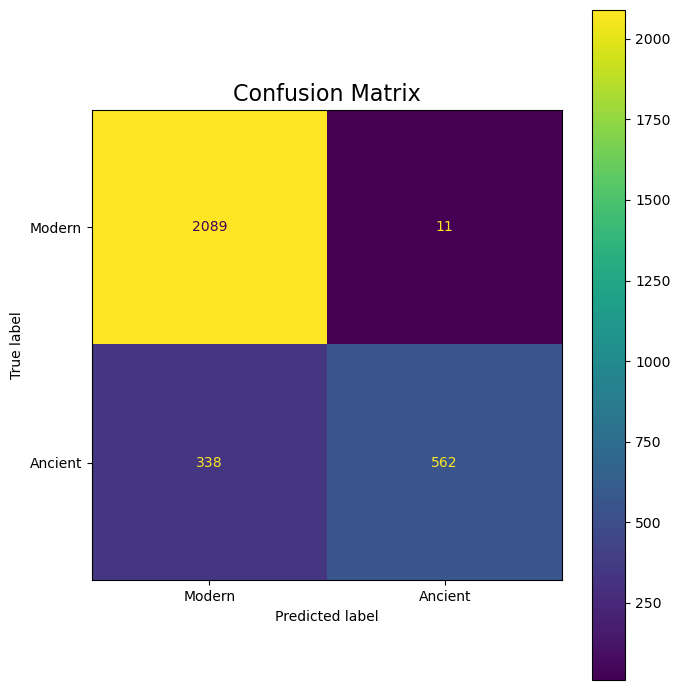

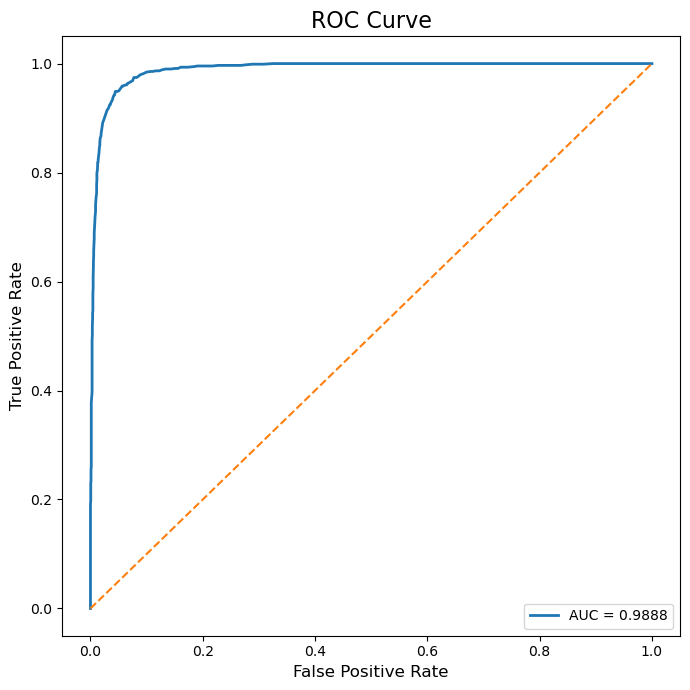

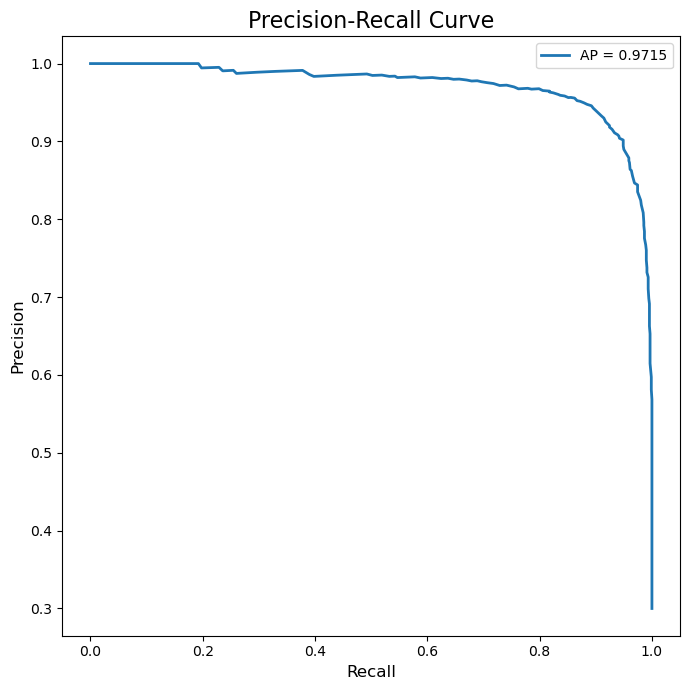


Calculating interpretable feature importances...


TOP IMPORTANT FEATURES



,Feature_Index,Importance,Read,Position,Base
822,822,0.009236,R2,38,G
802,802,0.008019,R2,34,G
912,912,0.007615,R2,56,G
972,972,0.006869,R2,68,G
917,917,0.006450,R2,57,G
762,762,0.006420,R2,26,G
937,937,0.006366,R2,61,G
637,637,0.006098,R2,1,G
892,892,0.005935,R2,52,G
1077,1077,0.005741,R2,89,G


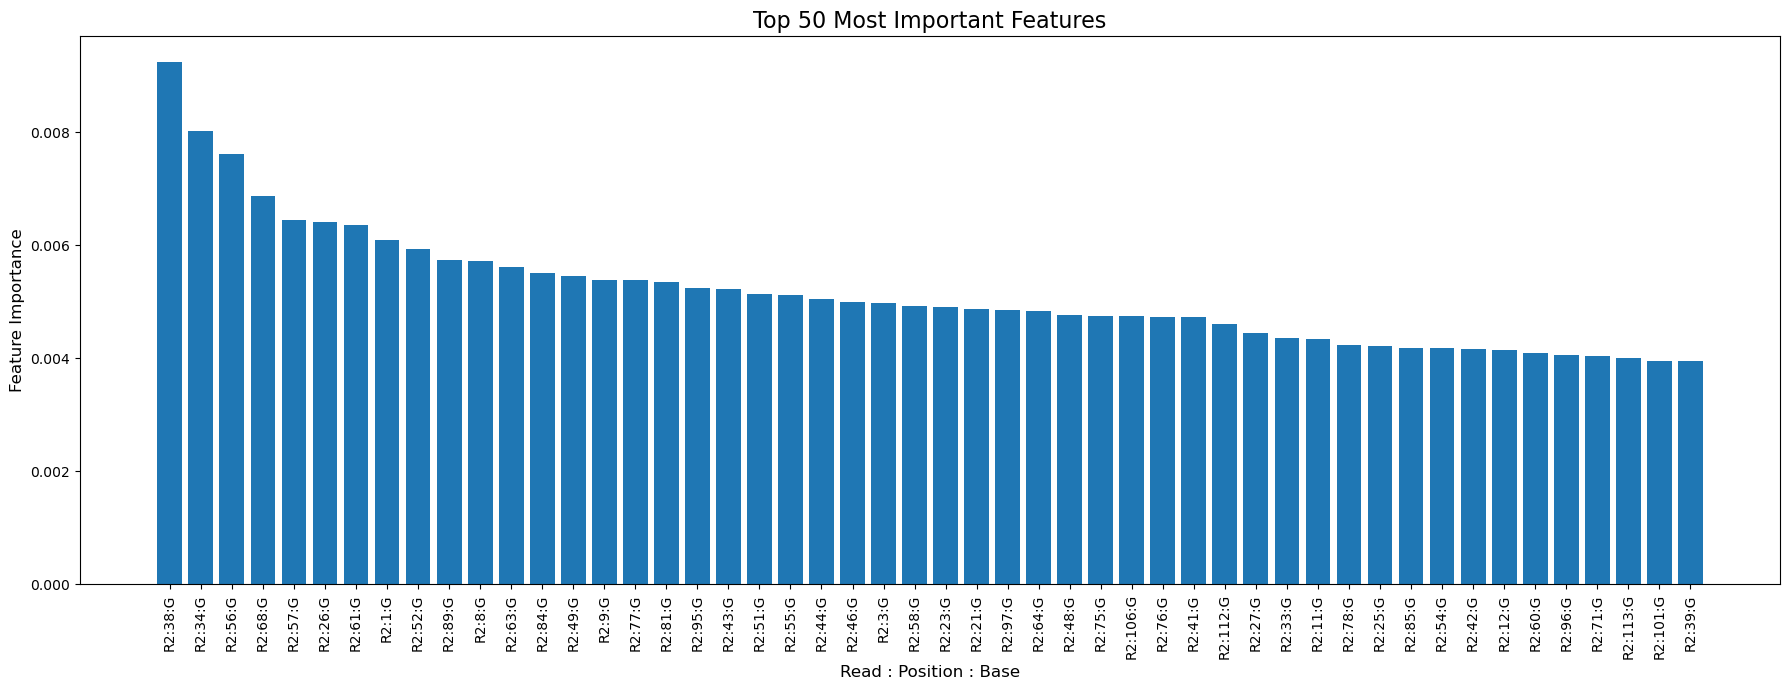


TOP POSITIONAL SIGNALS



,Read,Position,Importance
164,R2,38,0.011436
160,R2,34,0.010968
182,R2,56,0.009792
194,R2,68,0.009411
183,R2,57,0.009195
152,R2,26,0.009038
187,R2,61,0.008490
135,R2,9,0.008339
127,R2,1,0.008199
178,R2,52,0.008083


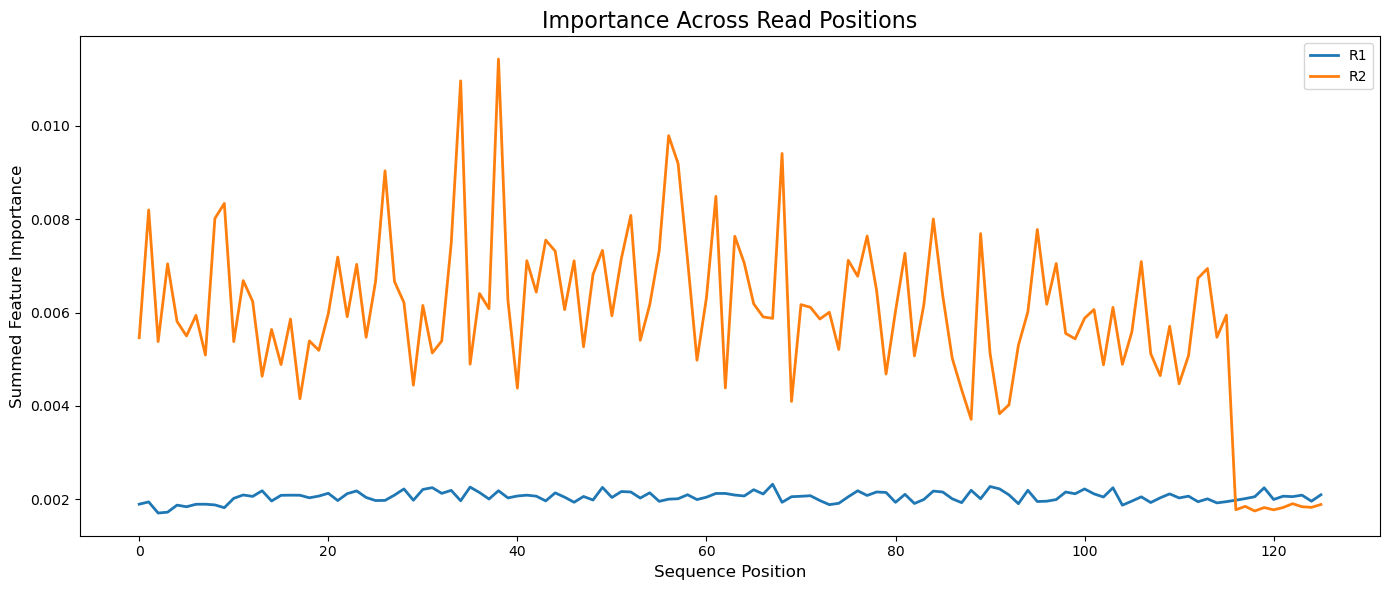


Running cross-validation...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   24.7s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   25.0s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   24.7s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   25.8s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   39.9s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  4


CROSS VALIDATION



,Fold,Accuracy
0,1,0.8877
1,2,0.8883
2,3,0.9010
3,4,0.8820
4,5,0.8913


Mean Accuracy: 0.8901
Std Accuracy : 0.0062

PER-DATASET PERFORMANCE



,Dataset,Accuracy,Precision,Recall,F1,N_Reads
2,dataset_4,0.9283,0.9951,0.7445,0.8518,990
1,dataset_3,0.9015,0.9751,0.6806,0.8016,985
0,dataset_2,0.8234,0.9701,0.4793,0.6416,1025


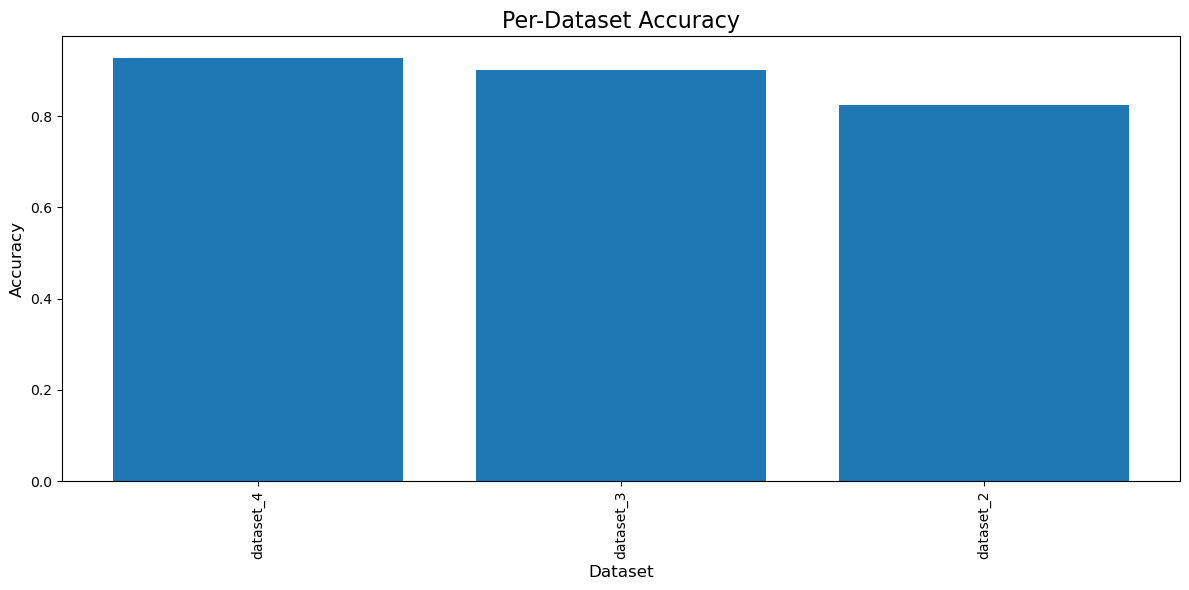


ANALYSIS COMPLETE

All results saved to:
/home/andrew/Documents/ML_prediction/data_sets/RF_RESULTS


In [6]:
# ============================================================
# RANDOM FOREST PIPELINE FOR ANCIENT DNA CLASSIFICATION
# ============================================================
#
# FEATURES:
# - Handles MULTIPLE datasets cleanly
# - Dataset-specific outputs
# - Combined model evaluation
# - Rich Jupyter notebook visualisation
# - Publication-quality figures
# - Tables displayed inline
# - Saves ALL outputs to results directory
# - ROC + PR + confusion matrix
# - Cross-validation statistics
# - Per-dataset performance summaries
# - Biologically interpretable feature importance
# - Positional importance profiling
#
# ============================================================

import os
import glob
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================================
# USER CONFIG
# ============================================================

data_dir = "/home/andrew/Documents/ML_prediction/data_sets/"

results_dir = os.path.join(data_dir, "RF_RESULTS")
os.makedirs(results_dir, exist_ok=True)

random_state = 42

# ============================================================
# FIND DATASETS
# ============================================================

X_files = sorted(
    glob.glob(
        os.path.join(data_dir, "X_data_*.npy")
    )
)

datasets = []

for x_file in X_files:

    dataset_name = (
        os.path.basename(x_file)
        .replace("X_data_", "")
        .replace(".npy", "")
    )

    y_file = os.path.join(
        data_dir,
        f"y_labels_{dataset_name}.npy"
    )

    if os.path.exists(y_file):

        datasets.append({
            "name": dataset_name,
            "X": x_file,
            "y": y_file
        })

print(f"\nFound {len(datasets)} datasets.\n")

# ============================================================
# LOAD ALL DATA
# ============================================================

X_all = []
y_all = []
dataset_labels = []

for ds in datasets:

    print(f"Loading: {ds['name']}")

    X = np.load(ds["X"])
    y = np.load(ds["y"])

    # Save original shape before flattening
    original_shape = X.shape

    # Flatten for Random Forest
    X = X.reshape(X.shape[0], -1)

    X_all.append(X)
    y_all.append(y)

    dataset_labels.extend([ds["name"]] * len(y))

X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)
dataset_labels = np.array(dataset_labels)

print("\n===================================")
print("COMBINED DATASET")
print("===================================")

print("X shape:", X_all.shape)
print("y shape:", y_all.shape)

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test, ds_train, ds_test = train_test_split(
    X_all,
    y_all,
    dataset_labels,
    test_size=0.2,
    stratify=y_all,
    random_state=random_state
)

# ============================================================
# RANDOM FOREST MODEL
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    n_jobs=-1,
    class_weight="balanced",
    random_state=random_state,
    verbose=1
)

print("\nTraining Random Forest...\n")

rf.fit(X_train, y_train)

# ============================================================
# SAVE MODEL
# ============================================================

model_path = os.path.join(
    results_dir,
    "random_forest_combined.joblib"
)

joblib.dump(rf, model_path)

print(f"\nSaved model:\n{model_path}")

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# ============================================================
# OVERALL METRICS
# ============================================================

overall_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "Average Precision": average_precision_score(y_test, y_prob)
}

metrics_df = pd.DataFrame(
    overall_metrics,
    index=["Combined Model"]
)

print("\n===================================")
print("OVERALL PERFORMANCE")
print("===================================\n")

display(metrics_df.round(4))

metrics_df.to_csv(
    os.path.join(results_dir, "overall_metrics.csv")
)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_test,
    y_pred,
    target_names=["Modern", "Ancient"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================\n")

display(report_df.round(4))

report_df.to_csv(
    os.path.join(results_dir, "classification_report.csv")
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(7, 7))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Modern", "Ancient"]
)

disp.plot(ax=ax)

plt.title("Confusion Matrix", fontsize=16)

plt.tight_layout()

plt.savefig(
    os.path.join(results_dir, "confusion_matrix.png"),
    dpi=300
)

plt.show()

# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "ROC Curve",
    fontsize=16
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(results_dir, "roc_curve.png"),
    dpi=300
)

plt.show()

# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

ap = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 7))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"AP = {ap:.4f}"
)

plt.xlabel(
    "Recall",
    fontsize=12
)

plt.ylabel(
    "Precision",
    fontsize=12
)

plt.title(
    "Precision-Recall Curve",
    fontsize=16
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "precision_recall_curve.png"
    ),
    dpi=300
)

plt.show()

# ============================================================
# INTERPRETABLE FEATURE IMPORTANCE
# ============================================================

print("\nCalculating interpretable feature importances...\n")

importances = rf.feature_importances_

# ------------------------------------------------------------
# FEATURE MAPPING
# ------------------------------------------------------------
#
# Original shape:
#
# (samples, sequence_length, 5)
#
# Flattened:
#
# feature_index = sequence_position * 5 + base_channel
#
# Channels:
# 0=A
# 1=C
# 2=G
# 3=T
# 4=N
#
# ------------------------------------------------------------

base_names = ["A", "C", "G", "T", "N"]

total_features = X_all.shape[1]

sequence_length = total_features // 5

# R1 + R2 concatenated
half_length = sequence_length // 2

feature_rows = []

for idx, importance in enumerate(importances):

    seq_position = idx // 5
    base_channel = idx % 5

    base = base_names[base_channel]

    if seq_position < half_length:

        read = "R1"
        read_position = seq_position

    else:

        read = "R2"
        read_position = seq_position - half_length

    feature_rows.append({
        "Feature_Index": idx,
        "Importance": importance,
        "Read": read,
        "Position": read_position,
        "Base": base
    })

feature_df = pd.DataFrame(feature_rows)

# ============================================================
# TOP IMPORTANT FEATURES
# ============================================================

top_n = 50

top_features = (
    feature_df
    .sort_values("Importance", ascending=False)
    .head(top_n)
)

print("\n===================================")
print("TOP IMPORTANT FEATURES")
print("===================================\n")

display(top_features.round(6))

top_features.to_csv(
    os.path.join(
        results_dir,
        "top_feature_importances.csv"
    ),
    index=False
)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(18, 7))

labels = [
    f"{r.Read}:{r.Position}:{r.Base}"
    for _, r in top_features.iterrows()
]

plt.bar(
    range(top_n),
    top_features["Importance"]
)

plt.xticks(
    range(top_n),
    labels,
    rotation=90
)

plt.xlabel(
    "Read : Position : Base",
    fontsize=12
)

plt.ylabel(
    "Feature Importance",
    fontsize=12
)

plt.title(
    f"Top {top_n} Most Important Features",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "interpretable_feature_importance.png"
    ),
    dpi=300
)

plt.show()

# ============================================================
# POSITIONAL IMPORTANCE PROFILE
# ============================================================

position_summary = (
    feature_df
    .groupby(["Read", "Position"])["Importance"]
    .sum()
    .reset_index()
)

top_positions = (
    position_summary
    .sort_values("Importance", ascending=False)
    .head(30)
)

print("\n===================================")
print("TOP POSITIONAL SIGNALS")
print("===================================\n")

display(top_positions.round(6))

top_positions.to_csv(
    os.path.join(
        results_dir,
        "top_positional_importance.csv"
    ),
    index=False
)

# ============================================================
# POSITIONAL IMPORTANCE PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

for read in ["R1", "R2"]:

    subset = (
        position_summary[
            position_summary["Read"] == read
        ]
        .sort_values("Position")
    )

    ax.plot(
        subset["Position"],
        subset["Importance"],
        linewidth=2,
        label=read
    )

ax.set_xlabel(
    "Sequence Position",
    fontsize=12
)

ax.set_ylabel(
    "Summed Feature Importance",
    fontsize=12
)

ax.set_title(
    "Importance Across Read Positions",
    fontsize=16
)

ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "positional_importance_profile.png"
    ),
    dpi=300
)

plt.show()

# ============================================================
# CROSS VALIDATION
# ============================================================

print("\nRunning cross-validation...\n")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

cv_scores = cross_val_score(
    rf,
    X_all,
    y_all,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

cv_df = pd.DataFrame({
    "Fold": np.arange(1, len(cv_scores)+1),
    "Accuracy": cv_scores
})

print("\n===================================")
print("CROSS VALIDATION")
print("===================================\n")

display(cv_df.round(4))

print(
    f"Mean Accuracy: {cv_scores.mean():.4f}"
)

print(
    f"Std Accuracy : {cv_scores.std():.4f}"
)

cv_df.to_csv(
    os.path.join(
        results_dir,
        "cross_validation_scores.csv"
    ),
    index=False
)

# ============================================================
# PER-DATASET PERFORMANCE
# ============================================================

print("\n===================================")
print("PER-DATASET PERFORMANCE")
print("===================================\n")

dataset_results = []

for dataset in np.unique(ds_test):

    mask = ds_test == dataset

    y_true_ds = y_test[mask]
    y_pred_ds = y_pred[mask]

    acc = accuracy_score(
        y_true_ds,
        y_pred_ds
    )

    prec = precision_score(
        y_true_ds,
        y_pred_ds
    )

    rec = recall_score(
        y_true_ds,
        y_pred_ds
    )

    f1 = f1_score(
        y_true_ds,
        y_pred_ds
    )

    dataset_results.append({
        "Dataset": dataset,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "N_Reads": len(y_true_ds)
    })

dataset_df = pd.DataFrame(dataset_results)

display(
    dataset_df
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .round(4)
)

dataset_df.to_csv(
    os.path.join(
        results_dir,
        "per_dataset_metrics.csv"
    ),
    index=False
)

# ============================================================
# DATASET ACCURACY PLOT
# ============================================================

plt.figure(figsize=(12, 6))

sorted_df = dataset_df.sort_values(
    "Accuracy",
    ascending=False
)

plt.bar(
    sorted_df["Dataset"],
    sorted_df["Accuracy"]
)

plt.xticks(rotation=90)

plt.ylabel(
    "Accuracy",
    fontsize=12
)

plt.xlabel(
    "Dataset",
    fontsize=12
)

plt.title(
    "Per-Dataset Accuracy",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        results_dir,
        "dataset_accuracy.png"
    ),
    dpi=300
)

plt.show()

# ============================================================
# SUMMARY FILE
# ============================================================

summary_path = os.path.join(
    results_dir,
    "summary.txt"
)

with open(summary_path, "w") as f:

    f.write("=====================================\n")
    f.write("RANDOM FOREST SUMMARY\n")
    f.write("=====================================\n\n")

    f.write(f"Total samples: {len(y_all)}\n")
    f.write(f"Features: {X_all.shape[1]}\n\n")

    for k, v in overall_metrics.items():
        f.write(f"{k}: {v:.4f}\n")

    f.write("\n")

    f.write(
        f"CV Mean Accuracy: "
        f"{cv_scores.mean():.4f}\n"
    )

    f.write(
        f"CV Std Accuracy: "
        f"{cv_scores.std():.4f}\n"
    )

print("\n===================================")
print("ANALYSIS COMPLETE")
print("===================================")

print(f"\nAll results saved to:\n{results_dir}")